# 2-D Ising Model

We will investigate the 2-d Ising model with Monte Carlo methods. Since there are many internal iterations, it is much faster to run in `C++` with `swig`. 

### Compile with swig

In [1]:
! swig -c++ -python swig/ising.i
! python swig/setup_ising.py build_ext --inplace

### Import from swig

In [2]:
import sys
import os
sys.path.append( os.path.abspath("swig") )
import ising
import numpy as np
import matplotlib.pyplot as plt

### Initialize the system

In [3]:
L = 10
J = 1.0
N = 100
T = 1.
H = 0.
MCSteps = 1000


### Run the simulations for various temperatures


Also plot the average magnetization as a function of the MC step. 

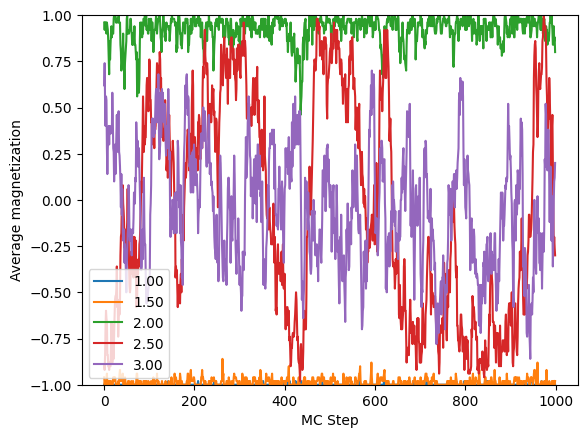

In [4]:
eAvgVals = []
mAvgVals = []
Tvals = np.linspace(1,3,5)
for T in Tvals:
    i = ising.Ising(J, L, N, T, H)
    i.run(MCSteps)
    mvals = i.get_mvals()
    plt.plot(mvals, label="%3.2f" % (T))
    eAvgVals.append( i.get_eAvg() )
    mAvgVals.append( i.get_mAvg() )

plt.legend()
plt.ylim(-1,1)
plt.xlabel("MC Step")
plt.ylabel("Average magnetization")
plt.show()

### Plot average magnetization versus temperature

Text(0, 0.5, 'Average Magnetization')

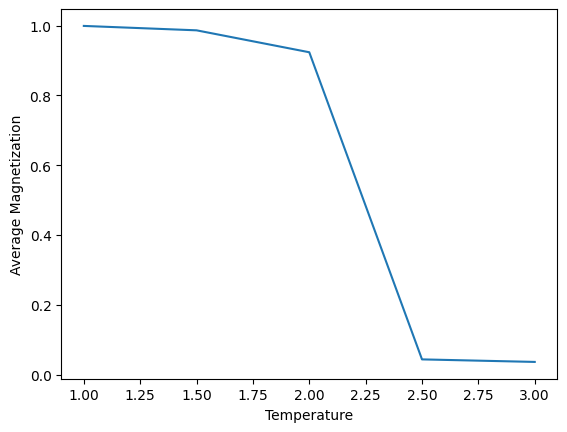

In [5]:
plt.plot(Tvals, np.abs(mAvgVals))
plt.xlabel("Temperature")
plt.ylabel("Average Magnetization")

# Part a)

All I'm doing here is giving a few values for L and N that are relatively similar to the values given in the example and I plot the magnetization.

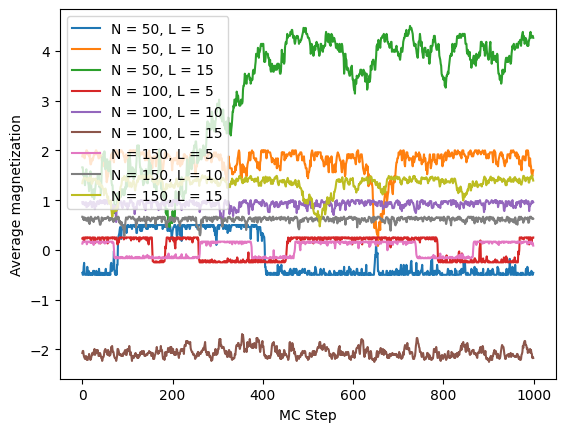

In [6]:
eAvgVals = []
mAvgVals = []
Tvals = np.linspace(1,3,5)
T = 2
Nvals = [50, 100, 150]
Lvals = [5, 10, 15]
for N in Nvals:
    for L in Lvals:
        i = ising.Ising(J, L, N, T, H)
        i.run(MCSteps)
        mvals = i.get_mvals()
        plt.plot(mvals, label=f'N = {N}, L = {L}')
        eAvgVals.append( i.get_eAvg() )
        mAvgVals.append( i.get_mAvg() )

plt.legend()
#plt.ylim(-1,1)
plt.xlabel("MC Step")
plt.ylabel("Average magnetization")
plt.show()

It seems that the higher the value of N the less flippy floppy the magnetization. 

# Part b)

For the second part, we just have to plot the average magnetization values for various T values and then plot the fit. The actual fitting function is $\propto (T_c - T)^\beta$ when $T_c < T$ and 0 otherwise. That's what I'm trying to capture in the next cell.

I end up setting L and N so that N is significantly larger than L. The physical intuition that I have for this is that if the density of particles is quite large then probability of all of them flipping will be quite low. 

The values we find are relativelt close to the expected.

$$ \beta_{Num} = 0.23 \quad\quad \beta_{Expected} = 1/8 $$
$$ T_{C, Num} = 2.35 \quad\quad T_{C, Expected} = 2.5ish $$

In [7]:
def magnetization_per_spin(T, T_c, beta):
    T = np.array(T)  #make T an array to avoid the truth issue later
    return np.where(T_c - T < 0, 0, (T_c - T)**beta)

In [8]:
eAvgVals = []
mAvgVals = []
Tvals = np.linspace(1,3,1000)
T = 2
N = 1000
L = 30
MCSteps = 1000

for T in Tvals:
    i = ising.Ising(J, L, N, T, H)
    i.run(MCSteps)
    mvals = i.get_mvals()
    
    eAvgVals.append( i.get_eAvg() )
    mAvgVals.append( i.get_mAvg() )

In [11]:
from scipy.optimize import curve_fit

pT = 1 #Proportion of Tvals that we want to fit. The data gets gross after a while so it won't do any good to fit it
popt, pcov = curve_fit(magnetization_per_spin, Tvals, Mvals, p0=[2.6, 0.125])

Tc_fit, beta_fit = popt

/tmp/ipykernel_5848/4292842579.py:3: RuntimeWarning: invalid value encountered in power
  return np.where(T_c - T < 0, 0, (T_c - T)**beta)


/tmp/ipykernel_5848/4292842579.py:3: RuntimeWarning: invalid value encountered in power
  return np.where(T_c - T < 0, 0, (T_c - T)**beta)


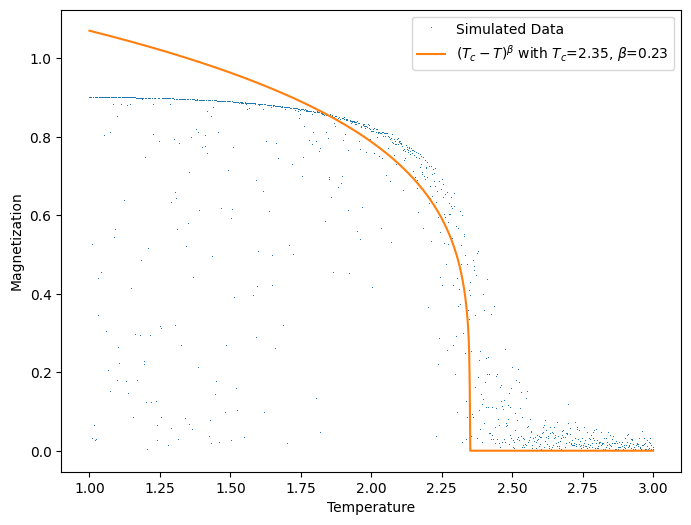

In [12]:
#m_fit_data = magnetization_fit(T_fit, Tc_fit, beta_fit)


plt.figure(figsize=(8, 6))
plt.plot(Tvals, Mvals, ',', label="Simulated Data")
plt.plot(Tvals, magnetization_per_spin(Tvals, Tc_fit, beta_fit), '-', label=f"$(T_c - T)^\\beta$ with $T_c$={Tc_fit:.2f}, $\\beta$={beta_fit:.2f}")
plt.xlabel("Temperature")
plt.ylabel("Magnetization")
plt.legend()
plt.show()

# Part c)

Relatively easy. We find that the specific heat peaks around the Curie Temperature as expected. There's quite a bit of noise bt the data is far from perfect. 

In [13]:
Evals = eAvgVals

Evals_smoothed = []

width = 50 #Window to average/smooth over
for i, E in enumerate(Evals):
    if i < len(Evals) - width:
        avg = np.sum(Evals[i:(i+width)])/width #only go up to i = -width because after that you'd start averaging the end of the list with the beginning of the list, which is nonsense.
        Evals_smoothed.append(avg)
    else: 
        pass

Tvals_Cplot = Tvals[0:-width] #Just make this the same length as Evals_smoothed

In [14]:
C = [Evals_smoothed[i+1] - Evals_smoothed[i] for i in range(len(Evals_smoothed)-1)]

C_plot  = C + [C[-1]]

Text(0, 0.5, 'Specific Heat ($C = dE/dT$)')

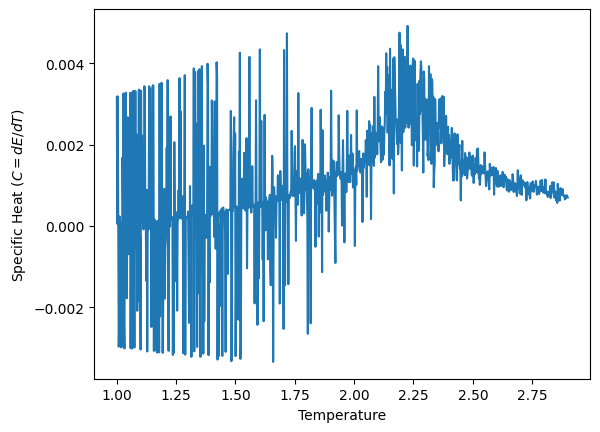

In [17]:
plt.plot(Tvals_Cplot, C_plot)
plt.xlabel('Temperature')
plt.ylabel(r'Specific Heat ($C = dE/dT$)')